# 神经网络的迭代与优化
# Neural Network Iteration and Optimization 



本教程将引导您了解训练神经网络过程中的核心概念，包括如何通过迭代寻找最优模型、如何处理训练中常见的“过拟合”与“欠拟合”问题，以及驱动模型学习的关键——优化算法。

This tutorial will guide you through the core concepts of training a neural network, including how to find the optimal model through iteration, how to handle common training problems like "overfitting" and "underfitting," and the key driver of model learning—optimization algorithms.

## 1. 神经网络的迭代概念
## 1. The Concept of Neural Network Iteration

在应用神经网络时，我们需要通过多次“迭代”来调整一系列“超参数”，以找到性能最好的模型。
When applying neural networks, we need to go through multiple "iterations" to adjust a series of "hyperparameters" to find the best-performing model.

这些超参数包括网络的层数、每层的神经元数量、学习率以及选择哪种激活函数等。
These hyperparameters include the number of network layers, the number of neurons per layer, the learning rate, and the choice of activation function.

这个过程通常是一个循环：
This process is typically a cycle:

1.  **构思与设计**: 设定一组超参数。
    **Idea & Design**: Set a group of hyperparameters.
2.  **编码与实验**: 用代码实现模型并进行训练。
    **Code & Experiment**: Implement the model in code and train it.
3.  **分析结果**: 检查模型在验证集上的表现。
    **Analyze Results**: Check the model's performance on a validation set.

根据结果，我们再回头调整超参数，开始新一轮的迭代，直到找到一个令人满意的模型。
Based on the results, we go back and adjust the hyperparameters to start a new iteration, continuing until we find a satisfactory model.

## 2. 核心挑战：训练误差 vs. 泛化误差
## 2. The Core Challenge: Training Error vs. Generalization Error

我们最终的目标是让模型在从未见过的新数据上表现良好。
Our ultimate goal is for the model to perform well on new, unseen data.

因此，需要理解两种误差：
Therefore, we need to understand two types of error:

* **训练误差 (Training Error)**: 模型在训练数据集上表现出的误差。
* **Training Error**: The error that the model exhibits on the training dataset.
* **泛化误差 (Generalization Error)**: 模型在任意新测试数据样本上误差的期望值。
* **Generalization Error**: The expected error of the model on any new test data sample.

**关键点**: 训练误差低，不代表泛化误差也低！
**Key Point**: A low training error does not necessarily mean a low generalization error!

一个好的模型需要同时降低这两种误差。
A good model needs to reduce both types of error.

## 3. 数据集划分：训练、验证与测试
## 3. Data Splitting: Train, Validation, and Test Sets

为了科学地评估和选择模型，我们需要合理地划分数据。
To scientifically evaluate and select models, we need to split our data appropriately.

* **训练集 (Training Set)**: 用于训练多个不同的模型。
* **Training Set**: Used to train multiple different models.
* **验证集 (Validation Set)**: 用于评估各个训练好的模型，并从中选出表现最好的一个或几个。
* **Validation Set**: Used to evaluate the various trained models and select the best one or two.
* **测试集 (Test Set)**: 用于在最后对选出的最优模型进行一次最终的、公正的性能评估（注意：测试集不是必须的）。
* **Test Set**: Used at the very end to perform a final, unbiased performance evaluation of the chosen best model (Note: The test set is not always necessary).

#### **划分比例 (Splitting Ratios)**

* **小数据集 (规模 < 百万)**:
* **Small Datasets (Size < 1 Million)**:
    * 方案一：训练集70%，测试集30%。然后从训练集中再分出10%作为验证集。
    * Option 1: 70% for training, 30% for testing. Then, take 10% from the training set to serve as the validation set.
    * 方案二：直接划分为 训练集60%，验证集20%，测试集20%。
    * Option 2: A direct split of 60% for training, 20% for validation, and 20% for testing.
* **大数据集 (规模 > 百万)**:
* **Large Datasets (Size > 1 Million)**:
    * 由于数据量巨大，验证集和测试集可以占据更小的比例，例如 98% / 1% / 1%，甚至更小。
    * Due to the large volume of data, the validation and test sets can be much smaller proportions, such as 98% / 1% / 1%, or even smaller.

## 4. 常见问题：欠拟合与过拟合
## 4. Common Problems: Underfitting and Overfitting

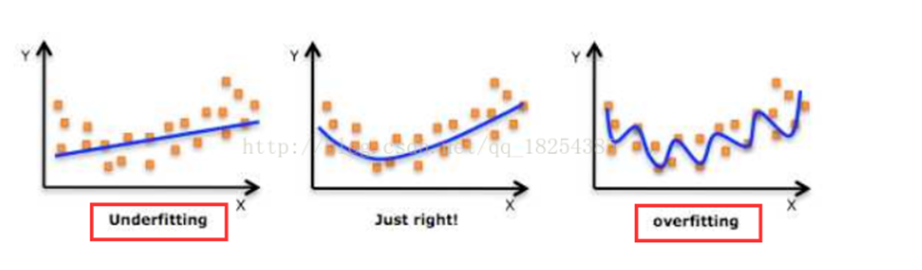

### **欠拟合 (Underfitting)**

* **定义**: 指模型过于简单，无法在训练集上获得足够低的误差，没能学习到数据背后的规律。
* **Definition**: Refers to a model that is too simple to achieve a sufficiently low error on the training set, failing to learn the underlying patterns in the data.
* **解决方法 (Solutions)**:
    * 增加模型复杂度，比如增加网络层数或神经元数量。
    * Increase model complexity, for instance, by adding more layers or neurons.
    * 增加新特征，给模型提供更多有用的信息。
    * Add new features to provide the model with more useful information.

### **过拟合 (Overfitting)**

* **定义**: 指模型在训练集上表现得“过于优秀”，把训练数据中的噪声和不重要的特征都学了进去，导致在新的验证集或测试集上表现不佳。
* **Definition**: Refers to a model that performs "too well" on the training set. It learns not only the signal but also the noise and unimportant features, leading to poor performance on new validation or test data.

举个例子：一个男人穿着蓝色的衣服，神经网络可能把是否穿蓝色衣服作为区分男人女人的特征，这就是过拟合

For example, if a man wears blue clothes, the neural network may use whether or not to wear blue clothes as a characteristic that distinguishes men and women, which is overfitting

* **产生原因 (Causes)**:
    * 模型参数过多，过于复杂。
    * The model has too many parameters and is overly complex.
    * 训练样本数量太少。
    * The number of training samples is too small.
    * 训练数据中噪声干扰过大。
    * There is too much noise in the training data.

### **如何防止过拟合？ (How to Prevent Overfitting?)**

我们的目标是显著降低测试误差，同时不过度增加训练误差。
Our goal is to significantly reduce the test error without excessively increasing the training error.

1.  **获取更多数据 (Get More Data)**: 这是最有效的方法。
    **Get More Data**: This is the most effective method.
    * **数据增强 (Data Augmentation)**: 对于图像，可以进行平移、翻转、缩放等操作来扩充数据集。
    * **Data Augmentation**: For images, we can expand the dataset through operations like translation, flipping, and scaling.

2.  **采用合适的模型 (Use an Appropriate Model)**: 控制模型的复杂度（网络的深度和宽度）。
    **Use an Appropriate Model**: Control the model's complexity (the depth and width of the network).

3.  **正则化 (Regularization)**: 在损失函数中加入一个惩罚项，限制模型参数的复杂度。
    **Regularization**: Add a penalty term to the loss function to constrain the complexity of the model's parameters.
    * **L2 正则化 (权重衰减)**: 惩罚项是所有权重 **w** 的平方和。它倾向于让权重值变得更小，但不会是0。
    * **L2 Regularization (Weight Decay)**: The penalty is the sum of the squares of all weights **w**. It encourages smaller weight values but doesn't force them to zero.
    * **L1 正则化**: 惩罚项是所有权重 **w** 的绝对值之和。它倾向于让一些不重要的权重直接变为0，从而产生“稀疏”的模型。
    * **L1 Regularization**: The penalty is the sum of the absolute values of all weights **w**. It encourages some unimportant weights to become exactly zero, creating a "sparse" model.

4.  **Dropout**: 在训练过程中，以一定概率随机地“丢弃”一些神经元，强迫网络学习到更鲁棒的特征。
    **Dropout**: During training, randomly "drop" (ignore) some neurons with a certain probability, forcing the network to learn more robust features.

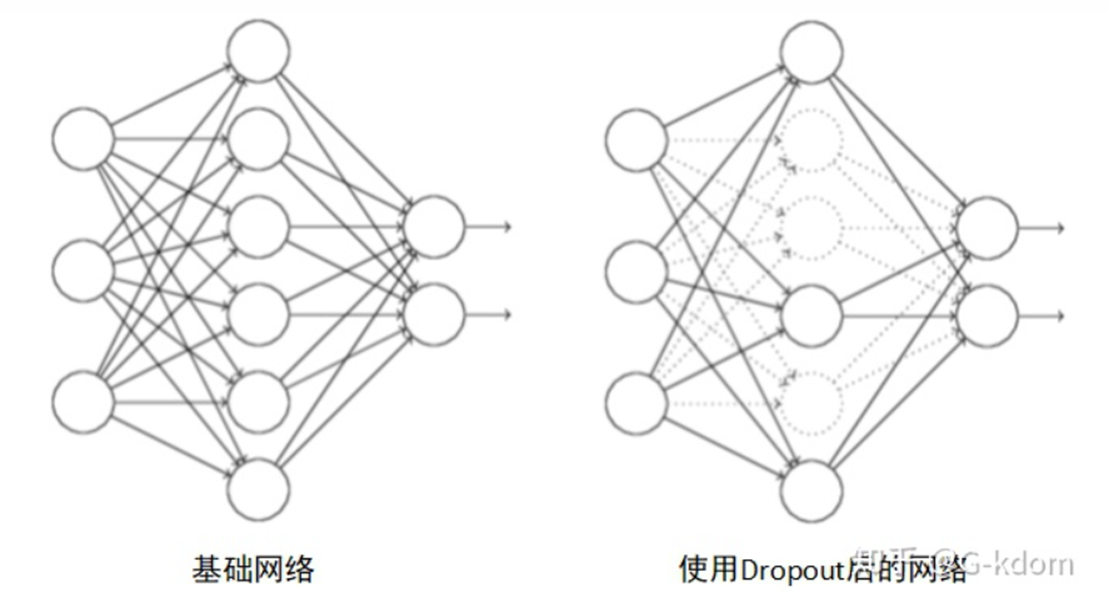

5.  **提前终止 (Early Stopping)**: 在训练过程中监控验证集的误差，当验证集误差不再下降时，就提前停止训练。
    **Early Stopping**: Monitor the error on the validation set during training; when the validation error stops decreasing, stop the training early.

## 5. 优化算法核心：梯度下降法
## 5. The Core of Optimization: Gradient Descent

优化算法的目标，是找到一组模型参数（权重 `w`），使得损失函数 `f(w)` 的值最小。
The goal of an optimization algorithm is to find a set of model parameters (weights `w`) that minimizes the value of the loss function `f(w)`.

梯度下降法是实现这一目标最经典和通用的算法。
Gradient Descent is the most classic and universal algorithm for achieving this goal.

#### **什么是梯度？ (What is a Gradient?)**

* **数学含义**: 梯度是一个向量，指向函数值上升最快的方向。
* **Mathematical Meaning**: A gradient is a vector that points in the direction of the fastest increase of a function.
* **我们的应用**: 因为我们想让损失函数**下降**，所以我们只需要沿着**梯度的反方向**前进。
* **Our Application**: Since we want to **decrease** the loss function, we simply need to move in the **opposite direction of the gradient**.

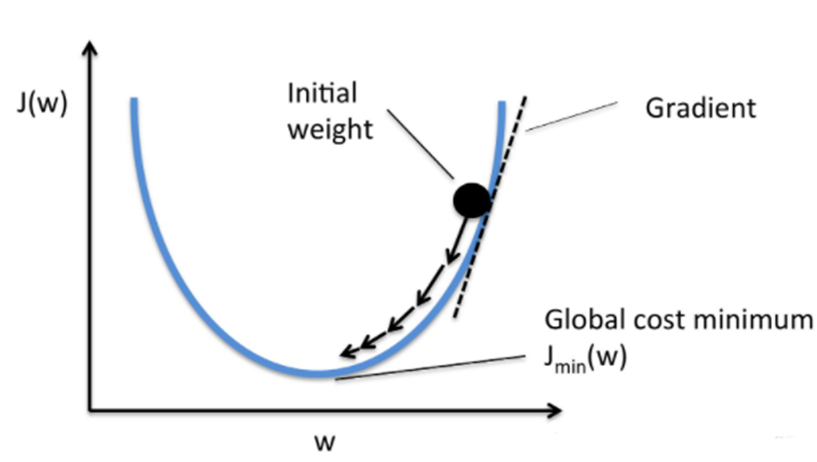

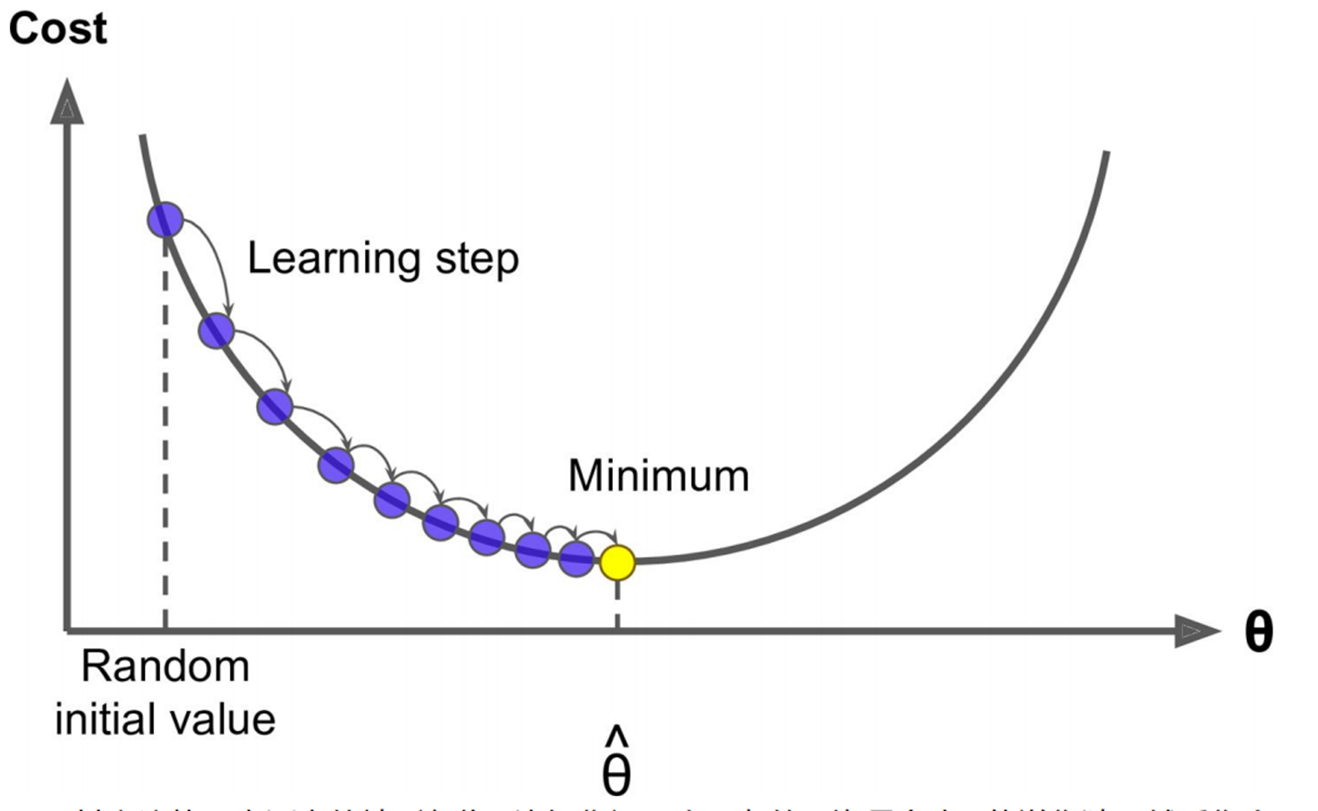

### **学习率的重要性 (The Importance of Learning Rate)**

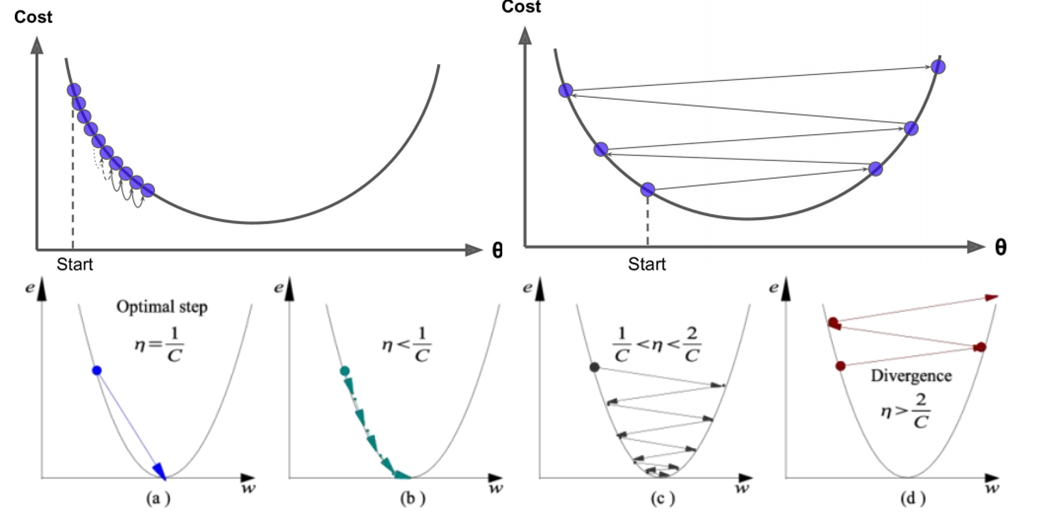


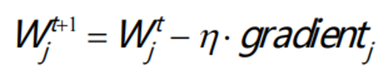

学习率（`η` 或 `α`）决定了我们下山时每一步迈多大。
The learning rate (`η` or `α`) determines the size of each step we take when descending.

* **学习率太小**: 下降速度会非常慢，训练时间很长。
* **Learning Rate Too Small**: The descent will be very slow, leading to long training times.
* **学习率太大**: 可能会“一步迈过”最低点，导致在谷底两侧来回震荡，甚至无法收敛。
* **Learning Rate Too Large**: We might "overshoot" the minimum, causing oscillations back and forth and potentially failing to converge.



选择一个合适的学习率至关重要。
Choosing an appropriate learning rate is crucial.

常见的取值有 `0.1`, `0.01`, `0.001` 等。
Common values include `0.1`, `0.01`, `0.001`, etc.

有时我们还会使用**学习率调度 (Learning Rate Schedules)**，让学习率随着训练的进行而逐渐减小。
Sometimes, we also use **Learning Rate Schedules**, which gradually decrease the learning rate as training progresses.

### **随机梯度下降 (Stochastic Gradient Descent - SGD)**

在实践中，我们几乎总是使用**随机梯度下降 (SGD)** 或其变体。
In practice, we almost always use **Stochastic Gradient Descent (SGD)** or its variants.

SGD的核心思想是，每次更新不使用全部训练数据，而是只用一个小的**批次 (batch)** 的数据。
The core idea of SGD is to use only a small **batch** of data for each update, rather than the full training set.

* **好处 (Benefits)**:
    1.  **效率高**: 对于大数据集，使用batch可以极大减少计算压力。
        **Efficiency**: For large datasets, using batches significantly reduces computational load.
    2.  **收敛快**: 当数据集中有很多冗余样本时，SGD的收敛速度通常更快。
        **Faster Convergence**: When the dataset contains many redundant samples, SGD often converges faster.

## 6. 参数初始化
## 6. Parameter Initialization

在训练开始前，我们需要给模型的参数（权重）赋一个初始值。
Before training begins, we need to assign initial values to the model's parameters (weights).

这就是**参数初始化**。
This is **parameter initialization**.

合适的初始化能加速模型的收敛，而不恰当的初始化可能导致梯度消失或梯度爆炸等问题。
Proper initialization can speed up model convergence, while improper initialization can lead to problems like vanishing or exploding gradients.

PyTorch在 `torch.nn.init` 模块中提供了多种初始化函数。
PyTorch provides various initialization functions in the `torch.nn.init` module.

In [1]:
import torch
import torch.nn as nn

# 创建一个示例张量
# Create an example tensor
w = torch.empty(3, 5)

# --- 均匀分布初始化 (Uniform Initialization) ---
# 从 U(0, 1) 的均匀分布中采样来填充张量
# Fills the tensor with values sampled from a uniform distribution U(0, 1)
nn.init.uniform_(w)
print("--- Uniform Initialization ---")
print(w)


# --- 正态分布初始化 (Normal Initialization) ---
# 从均值为0，标准差为1的正态分布中采样来填充张量
# Fills the tensor with values sampled from a normal distribution with mean=0 and std=1
nn.init.normal_(w, mean=0.0, std=1.0)
print("\n--- Normal Initialization (mean=0, std=1) ---")
print(w)

--- Uniform Initialization ---
tensor([[0.9504, 0.5101, 0.6211, 0.5709, 0.4574],
        [0.6614, 0.3340, 0.2461, 0.1085, 0.8666],
        [0.6494, 0.2553, 0.0491, 0.5398, 0.6366]])

--- Normal Initialization (mean=0, std=1) ---
tensor([[-0.3984, -2.5904, -0.3415, -0.0607, -0.0617],
        [-0.0615,  0.3467,  0.2194, -0.1325,  1.0438],
        [ 0.2969, -0.9638, -0.6621, -1.3450,  1.6896]])
